      TV  Radio  Newspaper  Sales
0  112.4   32.1       10.3   13.4
1  285.2    4.2       90.3   15.9
2  219.6    8.1       50.5   14.5
3  179.6   44.9       82.6   18.5
4   46.8   30.3       32.0   10.2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
               TV      Radio   Newspaper       Sales
count  200.000000  200.00000  200.000000  200.000000
mean   145.204000   25.21900   52.068000   14.499500
std     88.467603   14.64782   30.733042    4.936741
min      1.700000    0.30000    1.100000    1.400000
25%     68.550000   13.10000   25.525000   10.475000
50%    148.35000

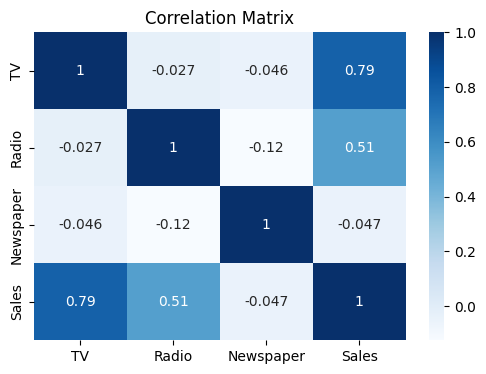

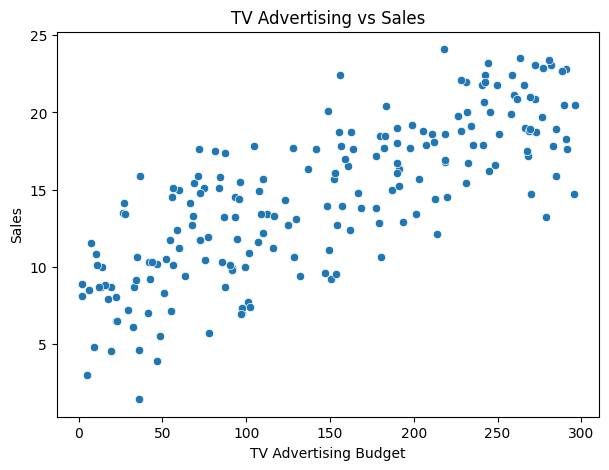

Intercept: 8.19894929779111
Coefficient: 0.04310110047099358

Model Performance
-------------------------
MAE : 2.2158569455252826
MSE : 7.145190713830291
RMSE: 2.673048954626587
R2 Score: 0.7013142360482445
     Actual  Predicted
95     13.9  14.582222
15      7.1  10.569510
30     17.7  16.056280
158    15.9  11.272058
128     8.1   8.289462
115    20.9  19.465577
69     20.5  20.961185
170    15.7  16.961403
174    12.9  16.543322
45     19.2  16.767448


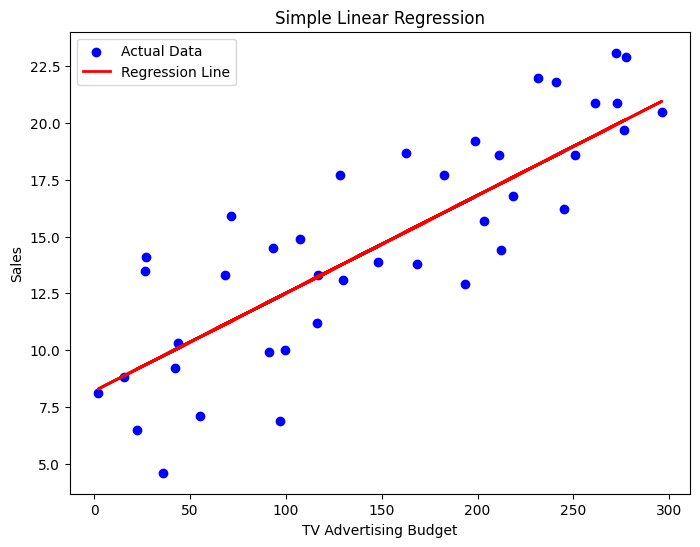

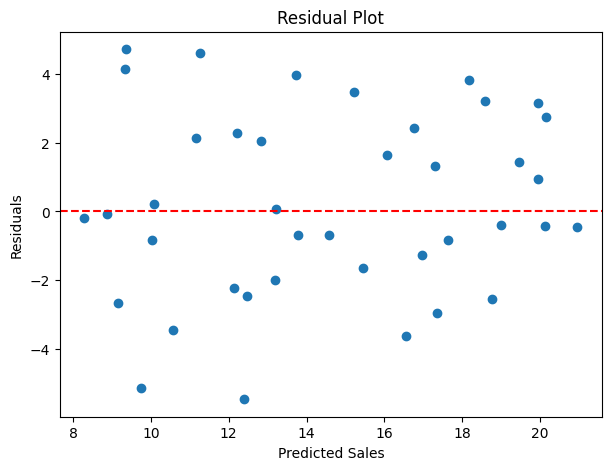

In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 2: Load Dataset
df = pd.read_csv("Advertising.csv")

# Step 3: Display First 5 Rows
print(df.head())

# Step 4: Dataset Information
print(df.info())

# Step 5: Check Missing Values
print(df.isnull().sum())

# Step 6: Statistical Summary
print(df.describe())

# Step 7: Correlation Matrix
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

# Step 8: Scatter Plot
plt.figure(figsize=(7,5))
sns.scatterplot(x="TV", y="Sales", data=df)
plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.show()

# Step 9: Select Features and Target
X = df[['TV']]
y = df['Sales']

# Step 10: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

# Step 11: Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 12: Predict
y_pred = model.predict(X_test)

# Step 13: Regression Equation
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

# Step 14: Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("-------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Step 15: Actual vs Predicted
result = pd.DataFrame({
    "Actual": y_test,
        "Predicted": y_pred
        })
print(result.head(10))

# Step 16: Regression Line
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color="blue", label="Actual Data")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Regression Line")
plt.title("Simple Linear Regression")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.legend()
plt.show()

# Step 17: Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()